# D09 — Sanity Check Visivo dei Dataset

Questo notebook verifica che la pipeline di caricamento dati funzioni correttamente **prima** di procedere con il training.

**Cosa viene controllato:**
- Le immagini si caricano senza errori
- Il pairing low/normal è corretto (stessa scena)
- I canali RGB sono nell'ordine corretto (niente inversioni BGR)
- Le immagini low sono effettivamente scure, le normal correttamente esposte
- Il preprocessing e l'augmentation producono tensori con shape e range attesi

**Eseguire D10** (overlap check) nella sessione successiva dopo aver verificato questo notebook.

## 1. Import e percorsi

In [6]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch

# Aggiunge la root del progetto al path (necessario su Kaggle)
PROJECT_ROOT = Path("/kaggle/input/low-light-repo") if Path("/kaggle").exists() else Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import PairedImageDataset
from src.data.transforms import (
    get_preprocessing_transform,
    get_paired_augmentation,
    SIZE_DEFAULT,
)


def require_path(path: Path, name: str) -> Path:
    """Verifica che un path esista, altrimenti solleva un errore chiaro."""
    if not path.exists():
        raise FileNotFoundError(f"{name} non trovato: {path}")
    return path


# Percorsi dataset
if Path("/kaggle").exists():
    DATA_ROOT   = Path("/kaggle/input")
    LOLV2_ROOT  = DATA_ROOT / "lol-v2-dataset" / "LOL-v2"
    LOLV1_ROOT  = DATA_ROOT / "lol-v1-dataset" / "LOL-v1"
    EXDARK_ROOT = DATA_ROOT / "exdark-dataset"  / "ExDark"
    # NOTA Kaggle: i nomi dipendono da come hai caricato i dataset in /kaggle/input.
    # Aggiorna i percorsi qui sopra se i nomi differiscono.
else:
    DATA_ROOT   = PROJECT_ROOT / "data"
    LOLV2_ROOT  = DATA_ROOT / "LOL-v2"
    LOLV1_ROOT  = DATA_ROOT / "LOL-v1"
    EXDARK_ROOT = DATA_ROOT / "ExDark"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data root    : {DATA_ROOT}")

require_path(LOLV2_ROOT,  "LOL-v2 root")
require_path(LOLV1_ROOT,  "LOL-v1 root")
require_path(EXDARK_ROOT, "ExDark root")

Project root : ..
Data root    : ..\data


WindowsPath('../data/ExDark')

## 2. Funzioni di utilità

In [7]:
def show_pairs(dataset, n=4, title=""):
    """Mostra n coppie low/normal affiancate con statistiche."""
    n = min(n, len(dataset))
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for col, idx in enumerate(range(n)):
        sample = dataset[idx]
        low    = np.array(sample["low"])
        normal = np.array(sample["normal"])

        axes[0, col].imshow(low)
        axes[0, col].set_title(f"LOW\n{sample['stem']}\nmean={low.mean():.1f}", fontsize=8)
        axes[0, col].axis("off")

        axes[1, col].imshow(normal)
        axes[1, col].set_title(f"NORMAL\nmean={normal.mean():.1f}", fontsize=8)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()


def check_dataset(dataset, name):
    """Stampa statistiche di base e verifica range valori."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Coppie totali : {len(dataset)}")

    sample = dataset[0]
    low    = np.array(sample["low"])
    normal = np.array(sample["normal"])

    print(f"  Shape (PIL)   : {low.shape}")
    print(f"  Low    — mean={low.mean():.1f}  min={low.min()}  max={low.max()}")
    print(f"  Normal — mean={normal.mean():.1f}  min={normal.min()}  max={normal.max()}")

    if low.mean() < normal.mean():
        print("  OK  low è più scura di normal")
    else:
        print("  ATTENZIONE: low NON è più scura di normal — verificare il pairing")

## 3. LOL-v2 Real


  LOL-v2 Real — Train
  Coppie totali : 689
  Shape (PIL)   : (400, 600, 3)
  Low    — mean=24.9  min=0  max=116
  Normal — mean=123.7  min=0  max=247
  OK  low è più scura di normal

  LOL-v2 Real — Test
  Coppie totali : 100
  Shape (PIL)   : (400, 600, 3)
  Low    — mean=13.6  min=0  max=255
  Normal — mean=108.2  min=3  max=255
  OK  low è più scura di normal


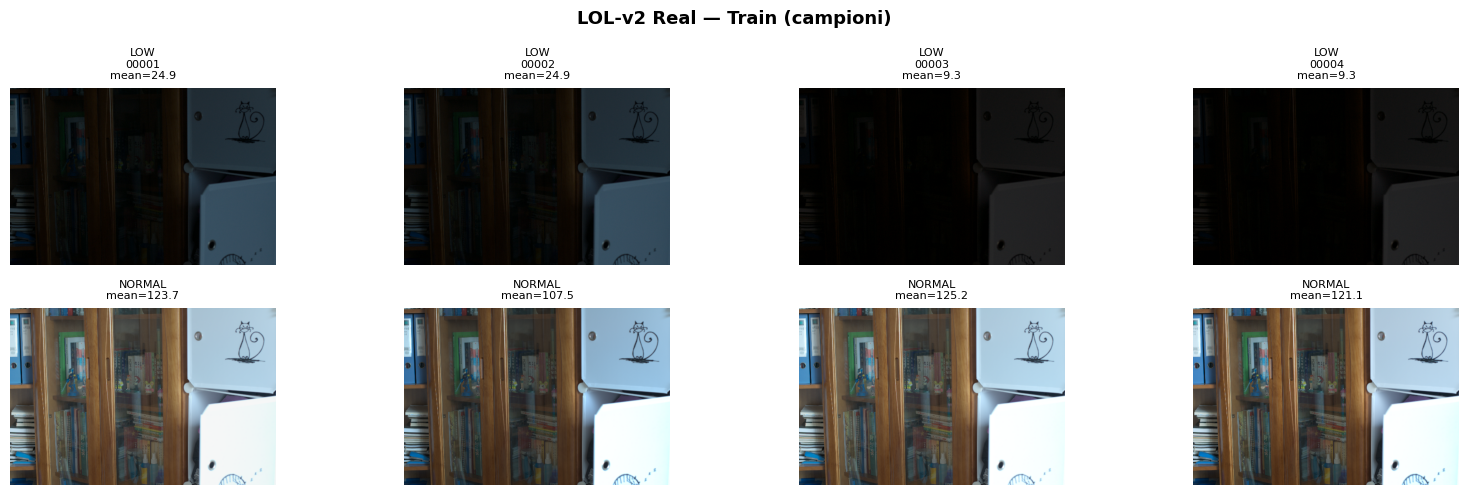

In [8]:
# LOL-v2 Real usa prefissi diversi: "low00001" / "normal00001"
# key_fn rimuove il prefisso alfabetico e accoppia per numero
lolv2_real_key = lambda s: s.lstrip("abcdefghijklmnopqrstuvwxyz")

lolv2_real_train = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Low",
    normal_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Normal",
    key_fn=lolv2_real_key,
)
lolv2_real_test = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Real_captured" / "Test" / "Low",
    normal_dir=LOLV2_ROOT / "Real_captured" / "Test" / "Normal",
    key_fn=lolv2_real_key,
)

check_dataset(lolv2_real_train, "LOL-v2 Real — Train")
check_dataset(lolv2_real_test,  "LOL-v2 Real — Test")
show_pairs(lolv2_real_train, n=4, title="LOL-v2 Real — Train (campioni)")

## 4. LOL-v2 Synthetic


  LOL-v2 Synthetic — Train
  Coppie totali : 900
  Shape (PIL)   : (384, 384, 3)
  Low    — mean=40.9  min=0  max=255
  Normal — mean=144.6  min=0  max=249
  OK  low è più scura di normal

  LOL-v2 Synthetic — Test
  Coppie totali : 100
  Shape (PIL)   : (384, 384, 3)
  Low    — mean=27.0  min=0  max=255
  Normal — mean=120.6  min=0  max=255
  OK  low è più scura di normal


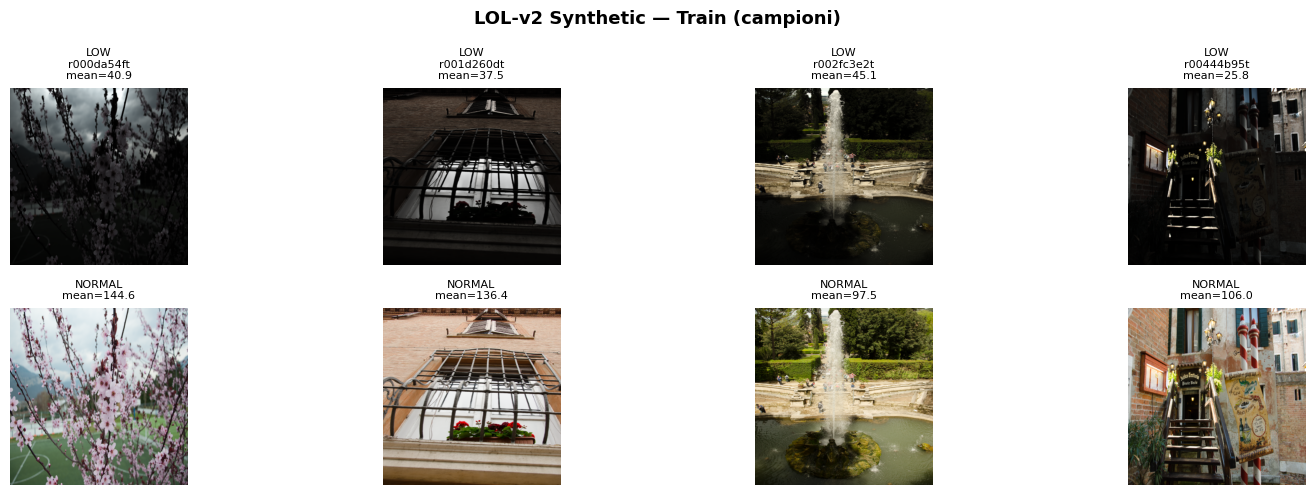

In [9]:
lolv2_synth_train = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Synthetic" / "Train" / "Low",
    normal_dir=LOLV2_ROOT / "Synthetic" / "Train" / "Normal",
)
lolv2_synth_test = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Synthetic" / "Test" / "Low",
    normal_dir=LOLV2_ROOT / "Synthetic" / "Test" / "Normal",
)

check_dataset(lolv2_synth_train, "LOL-v2 Synthetic — Train")
check_dataset(lolv2_synth_test,  "LOL-v2 Synthetic — Test")
show_pairs(lolv2_synth_train, n=4, title="LOL-v2 Synthetic — Train (campioni)")

## 5. LOL-v1


  LOL-v1 — our485 (train)
  Coppie totali : 485
  Shape (PIL)   : (400, 600, 3)
  Low    — mean=14.3  min=0  max=51
  Normal — mean=129.1  min=0  max=219
  OK  low è più scura di normal

  LOL-v1 — eval15 (test)
  Coppie totali : 15
  Shape (PIL)   : (400, 600, 3)
  Low    — mean=24.9  min=0  max=116
  Normal — mean=123.8  min=0  max=255
  OK  low è più scura di normal


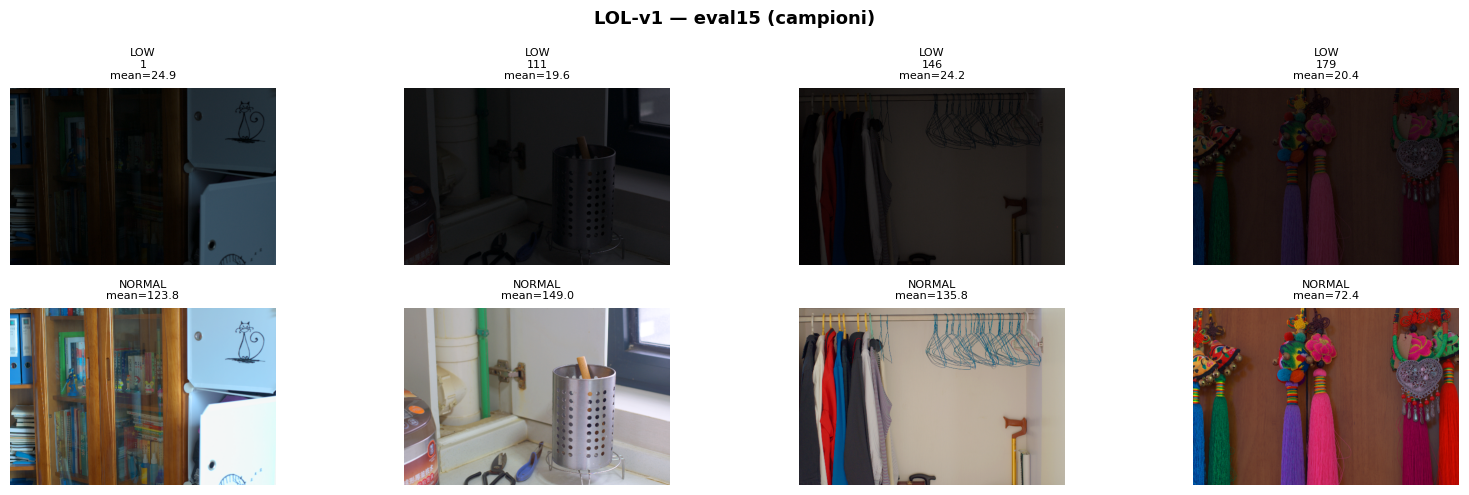

In [10]:
# LOL-v1 ha 2 immagini low senza ground truth (522, 735): strict=False le salta
lolv1_train = PairedImageDataset(
    low_dir=LOLV1_ROOT / "our485" / "low",
    normal_dir=LOLV1_ROOT / "our485" / "high",
    strict=False,
)
lolv1_test = PairedImageDataset(
    low_dir=LOLV1_ROOT / "eval15" / "low",
    normal_dir=LOLV1_ROOT / "eval15" / "high",
)

check_dataset(lolv1_train, "LOL-v1 — our485 (train)")
check_dataset(lolv1_test,  "LOL-v1 — eval15 (test)")
show_pairs(lolv1_test, n=4, title="LOL-v1 — eval15 (campioni)")

## 6. ExDark (unpaired)

ExDark — immagini campionate: 12 su totale 6438
Classi campionate: ['Bicycle']


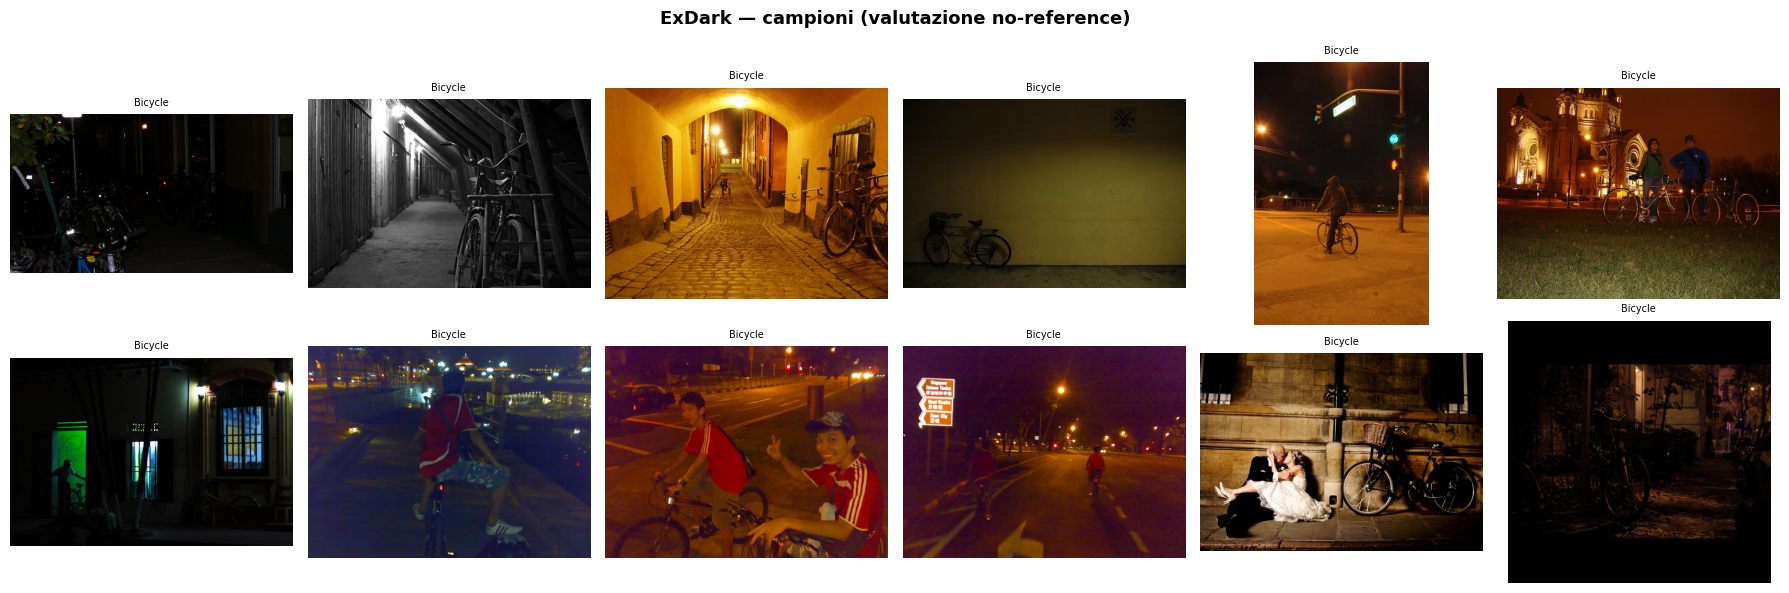

In [11]:
from PIL import Image as PILImage

all_exdark_images = sorted(EXDARK_ROOT.rglob("*.jpg"))
exdark_images = all_exdark_images[:12]

print(f"ExDark — immagini campionate: {len(exdark_images)} su totale {len(all_exdark_images)}")
classes = sorted({p.parent.name for p in exdark_images})
print(f"Classi campionate: {classes}")

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("ExDark — campioni (valutazione no-reference)", fontsize=13, fontweight="bold")

for ax in axes.flat:
    ax.axis("off")

for ax, img_path in zip(axes.flat, exdark_images):
    img = PILImage.open(img_path).convert("RGB")
    ax.imshow(np.array(img))
    ax.set_title(f"{img_path.parent.name}", fontsize=7)

plt.tight_layout()
plt.show()

## 7. Verifica pipeline completa (preprocessing + augmentation)

In [12]:
preprocessing = get_preprocessing_transform(SIZE_DEFAULT)
augmentation  = get_paired_augmentation(SIZE_DEFAULT)

# Dataset di training con entrambe le trasformazioni
train_ds = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Low",
    normal_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Normal",
    key_fn=lolv2_real_key,
    paired_transform=augmentation,
    transform=preprocessing,
)
sample = train_ds[0]

low_t    = sample["low"]
normal_t = sample["normal"]

print("Pipeline training:")
print(f"  low shape    : {low_t.shape}  — atteso (3, {SIZE_DEFAULT}, {SIZE_DEFAULT})")
print(f"  normal shape : {normal_t.shape}")
print(f"  low range    : [{low_t.min():.3f}, {low_t.max():.3f}]  — atteso [0, 1]")
print(f"  normal range : [{normal_t.min():.3f}, {normal_t.max():.3f}]")
print(f"  dtype        : {low_t.dtype}  — atteso torch.float32")

assert low_t.shape    == (3, SIZE_DEFAULT, SIZE_DEFAULT)
assert normal_t.shape == (3, SIZE_DEFAULT, SIZE_DEFAULT)
assert low_t.min() >= 0.0 and low_t.max() <= 1.0
assert low_t.dtype == torch.float32
print("\n  Tutti gli assert superati — pipeline OK")

Pipeline training:
  low shape    : torch.Size([3, 256, 256])  — atteso (3, 256, 256)
  normal shape : torch.Size([3, 256, 256])
  low range    : [0.000, 0.435]  — atteso [0, 1]
  normal range : [0.071, 0.969]
  dtype        : torch.float32  — atteso torch.float32

  Tutti gli assert superati — pipeline OK


## 8. Confronto visivo: prima e dopo preprocessing

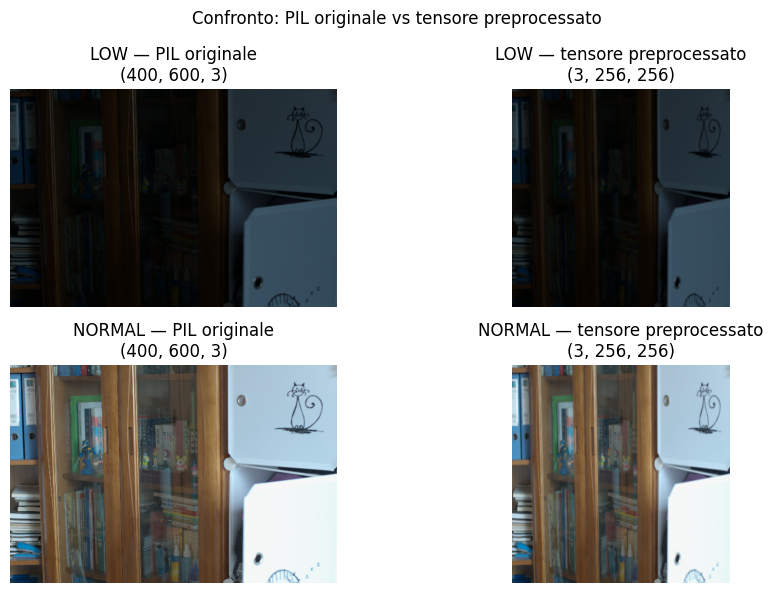

In [13]:
raw_ds = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Low",
    normal_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Normal",
    key_fn=lolv2_real_key,
)

proc_ds = PairedImageDataset(
    low_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Low",
    normal_dir=LOLV2_ROOT / "Real_captured" / "Train" / "Normal",
    key_fn=lolv2_real_key,
    transform=preprocessing,
)

idx = 0
raw_sample  = raw_ds[idx]
proc_sample = proc_ds[idx]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("Confronto: PIL originale vs tensore preprocessato", fontsize=12)

axes[0, 0].imshow(np.array(raw_sample["low"]))
axes[0, 0].set_title(f"LOW — PIL originale\n{np.array(raw_sample['low']).shape}")
axes[0, 0].axis("off")

axes[0, 1].imshow(proc_sample["low"].permute(1, 2, 0).numpy())
axes[0, 1].set_title(f"LOW — tensore preprocessato\n{tuple(proc_sample['low'].shape)}")
axes[0, 1].axis("off")

axes[1, 0].imshow(np.array(raw_sample["normal"]))
axes[1, 0].set_title(f"NORMAL — PIL originale\n{np.array(raw_sample['normal']).shape}")
axes[1, 0].axis("off")

axes[1, 1].imshow(proc_sample["normal"].permute(1, 2, 0).numpy())
axes[1, 1].set_title(f"NORMAL — tensore preprocessato\n{tuple(proc_sample['normal'].shape)}")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 9. D10 — Verifica assenza di sovrapposizione tra i dataset

Controlla che gli stem dei file di **training LOL-v2** non compaiano nei set di valutazione:
- LOL-v2 Test (Real + Synthetic) — sanity check interno
- LOL-v1 (our485 + eval15)
- ExDark (tutti i file .jpg)

La verifica è basata sul nome file (stem). Non rileva scene doppie con nomi diversi,
ma è sufficiente per escludere data leakage diretto tra i dataset usati in questo progetto.

In [14]:
def collect_stems(directory: Path, glob: str = "*") -> set:
    """Raccoglie gli stem dei file immagine in una cartella (non ricorsivo)."""
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}
    return {p.stem for p in directory.glob(glob) if p.suffix.lower() in exts}


def collect_stems_recursive(directory: Path) -> set:
    """Raccoglie gli stem di tutti i file immagine in modo ricorsivo."""
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tiff"}
    return {p.stem for p in directory.rglob("*") if p.suffix.lower() in exts}


# --- Raccolta stems LOL-v2 Train (sorgente di training) ---
lolv2_real_train_stems  = collect_stems(LOLV2_ROOT / "Real_captured" / "Train" / "Low")
lolv2_synth_train_stems = collect_stems(LOLV2_ROOT / "Synthetic"     / "Train" / "Low")
lolv2_train_stems = lolv2_real_train_stems | lolv2_synth_train_stems

# --- Raccolta stems set di valutazione ---
lolv2_real_test_stems  = collect_stems(LOLV2_ROOT / "Real_captured" / "Test" / "Low")
lolv2_synth_test_stems = collect_stems(LOLV2_ROOT / "Synthetic"     / "Test" / "Low")
lolv2_test_stems = lolv2_real_test_stems | lolv2_synth_test_stems

lolv1_our485_stems = collect_stems(LOLV1_ROOT / "our485" / "low")
lolv1_eval15_stems = collect_stems(LOLV1_ROOT / "eval15" / "low")
lolv1_stems = lolv1_our485_stems | lolv1_eval15_stems

exdark_stems = collect_stems_recursive(EXDARK_ROOT)

# --- Controllo sovrapposizioni ---
checks = [
    ("LOL-v2 Train", "LOL-v2 Test",  lolv2_train_stems & lolv2_test_stems),
    ("LOL-v2 Train", "LOL-v1 (all)", lolv2_train_stems & lolv1_stems),
    ("LOL-v2 Train", "ExDark",       lolv2_train_stems & exdark_stems),
]

sep = "=" * 60
print("Stems raccolti:")
print(f"  LOL-v2 Train  : {len(lolv2_real_train_stems)} real + {len(lolv2_synth_train_stems)} synth = {len(lolv2_train_stems)} totali")
print(f"  LOL-v2 Test   : {len(lolv2_real_test_stems)} real + {len(lolv2_synth_test_stems)} synth = {len(lolv2_test_stems)} totali")
print(f"  LOL-v1        : {len(lolv1_our485_stems)} our485 + {len(lolv1_eval15_stems)} eval15 = {len(lolv1_stems)} totali")
print(f"  ExDark        : {len(exdark_stems)} totali")

print(f"\n{sep}")
print("  RIEPILOGO OVERLAP CHECK")
print(sep)

all_ok = True
for src, dst, overlap in checks:
    status = "OK  " if len(overlap) == 0 else "ATTENZIONE"
    if len(overlap) > 0:
        all_ok = False
    print(f"  {status}  {src} \u2229 {dst} = {len(overlap)} stem(s)")
    if overlap:
        print(f"         Stem sovrapposti: {sorted(overlap)[:10]}")

print(sep)
if all_ok:
    print("  Nessun overlap rilevato \u2014 dataset isolati correttamente.")
else:
    print("  OVERLAP RILEVATO \u2014 verificare la struttura dei dataset.")

print()
print("Nota: il controllo \u00e8 basato sullo stem del nome file.")
print("Scene doppie con nomi file diversi non vengono rilevate,")
print("ma LOL-v2, LOL-v1 ed ExDark sono raccolte indipendenti.")


Stems raccolti:
  LOL-v2 Train  : 689 real + 900 synth = 1589 totali
  LOL-v2 Test   : 100 real + 100 synth = 200 totali
  LOL-v1        : 485 our485 + 15 eval15 = 500 totali
  ExDark        : 7363 totali

  RIEPILOGO OVERLAP CHECK
  OK    LOL-v2 Train ∩ LOL-v2 Test = 0 stem(s)
  OK    LOL-v2 Train ∩ LOL-v1 (all) = 0 stem(s)
  OK    LOL-v2 Train ∩ ExDark = 0 stem(s)
  Nessun overlap rilevato — dataset isolati correttamente.

Nota: il controllo è basato sullo stem del nome file.
Scene doppie con nomi file diversi non vengono rilevate,
ma LOL-v2, LOL-v1 ed ExDark sono raccolte indipendenti.
